# TEBOL end to end, on one photograph

Text-Based Embedding for Object Localization: caption an image, embed the
words, classify the mean, split the logit back onto the words, box the top one.

Phases A, B and D call the Qwen server; phase C uses the cached embeddings.

In [1]:
import os, sys
from pathlib import Path
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

for line in (ROOT / ".env").read_text().splitlines():
    if line.strip() and not line.startswith("#") and "=" in line:
        k, _, v = line.partition("=")
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

PAIR, N_WORDS = "cucumber_zucchini", 5
print(f"repo root: {ROOT.name}/")

repo root: TEBOL/


## Pick an image, held out of training below.

n07716358_10227 | zucchini


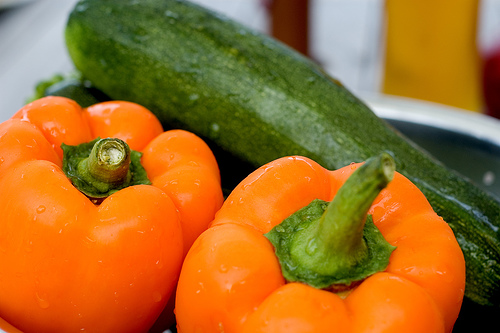

In [2]:
from PIL import Image

img_path = sorted((ROOT / "data" / "raw" / PAIR / "zucchini").glob("*.JPEG"))[7]
stem, true_class = img_path.stem, img_path.parent.name
print(stem, "|", true_class)
Image.open(img_path)

## Phase A — Captioning

The model is told only the word count.

In [3]:
from tebol.captioners import get_captioner, build_prompt

cap = get_captioner("local")
print(build_prompt(N_WORDS))

res = cap.caption(img_path, n_words=N_WORDS, temperature=1.0, seed=0)
caption = res.text
caption

Describe this image in 5 words.


'Fresh orange peppers and zucchini.'

## Phase B — Embedding

Each word becomes a vector; the caption is their mean, $\tilde A = \frac1n\sum_i \mathbf e_i$.

In [4]:
from tebol.text import tokenize
from tebol.embedders import get_embedder

words = tokenize(caption, split_hyphens=False)
emb = get_embedder("local")
out = emb.embed(words)
assert out.vectors is not None, out.error
E = np.asarray(out.vectors, dtype=np.float32)   # [n_words, 2560]
A = E.mean(axis=0)                              # the caption vector

print(words)
print("word vectors", E.shape, " caption vector", A.shape)

['fresh', 'orange', 'peppers', 'and', 'zucchini']
word vectors (5, 2560)  caption vector (2560,)


## Phase C — Concept discovery

Logistic regression on $\tilde A$, and its logit splits exactly across the words:

$$\text{logit}(S) = b + \frac1n\sum_i \underbrace{(\boldsymbol\beta\cdot\mathbf e_i)}_{z_i}$$

In [5]:
from sklearn.linear_model import LogisticRegression
from tebol.arms import load_arm, caption_means, nonempty

data = load_arm(ROOT, PAIR, "caption", N_WORDS)
X, y = caption_means(data), data.cls
keep = nonempty(data) & (data.stem != stem)          # hold this image out
clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X[keep], y[keep])

neg, pos = clf.classes_
z = E @ clf.coef_.ravel()                            # one score per word
b = float(clf.intercept_[0])
logit = b + z.mean()

print(f"{'word':<16}{'z':>9}{'z/n':>9}")
for w, zi in sorted(zip(words, z), key=lambda t: -abs(t[1])):
    print(f"{w:<16}{zi:>9.3f}{zi/len(words):>9.3f}")

print(f"\nb + mean(z) = {logit:+.4f}   model = {float(clf.decision_function([A])[0]):+.4f}")
print(f"predicted {pos if logit > 0 else neg}   true {true_class}")

word                    z      z/n
zucchini           14.092    2.818
orange              1.713    0.343
fresh              -1.241   -0.248
peppers            -1.078   -0.216
and                 0.354    0.071

b + mean(z) = +1.6849   model = +1.6849
predicted zucchini   true zucchini


## Phase D — Localization

The three highest-scoring words go back to the vision model.

In [6]:
from tebol import bbox as B

top3 = [w for w, _ in sorted(zip(words, z), key=lambda t: -t[1])[:3]]
prompt = B.build_prompt(top3)
print(prompt)

res = cap.ask(img_path, prompt, max_tokens=512, temperature=0.0, seed=0)
print(repr(res.text))

Provide bounding box coordinates for the object from (zucchini, orange, and). Format: x_min, y_min, x_max, y_max with integers only.


'127, 0, 998, 919'


Qwen answers on a 0–1000 grid, so the box is rescaled to pixels.

In [7]:
boxes, err = B.parse_boxes(res.text)
W, H = Image.open(img_path).size
px = [B.rescale(bx["box"], W, H)[0] for bx in boxes]

print("parse:", err or "ok")
for bx, p in zip(boxes, px):
    print(f"  {str(bx['label']):<12}{str(bx['box']):<26} -> {p}")

parse: ok
  None        [127, 0, 998, 919]         -> [64, 0, 499, 306]


Red is TEBOL's box, green is ImageNet's.

TEBOL (red, 'zucchini') [64, 0, 499, 306]
ImageNet (green)         [64, 1, 499, 309]
IoU 0.987


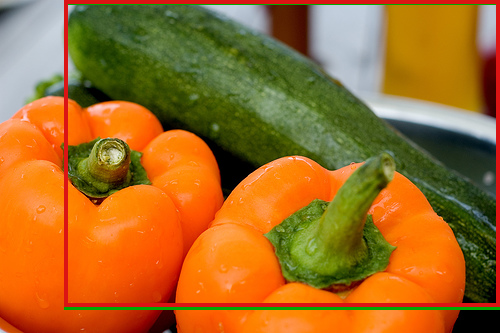

In [8]:
from PIL import ImageDraw

xml = ROOT / "data" / "annotations" / PAIR / true_class / f"{stem}.xml"
truth = B.truth_boxes(xml)[0] if xml.exists() else []

im = Image.open(img_path).convert("RGB")
d = ImageDraw.Draw(im)
wide = max(4, min(im.size) // 90)
for t in truth:
    d.rectangle(t, outline=(0, 170, 0), width=wide)
d.rectangle(px[0], outline=(220, 20, 20), width=wide)

print(f"TEBOL (red, '{top3[0]}') {px[0]}")
if truth:
    print(f"ImageNet (green)         {truth[0]}")
    print(f"IoU {B.best_iou(px[0], truth):.3f}")
im